In [1]:
import time
import h5py

import numpy as np
import matplotlib.pyplot as plt

import sys
from chemrixs.smalldata import SmallData
from chemrixs.process import Reduced
from chemrixs.utils import *
%matplotlib widget 

In [2]:
base_folder =  '/sdf/data/lcls/ds/rix/'
#run = 104 #XAS step mono
#run = 119 #waveplate
#run = 151 #fixed energy
#run = 76 #XAS fly mono

bgrun = 3

# runs_to_load = [398,399,400,401,402,403,404]
run = 400

#exp = 'rix100836924'
exp = 'rix101265125'
#79,81,82,83,85,94,95,96,98



#fname = f'/sdf/data/lcls/ds/rix/rix100836924/scratch/h5/rix100836924_Run{run:04d}.h5'
#bgname = f'/sdf/data/lcls/ds/rix/rix100836924/scratch/h5/rix100836924_Run{bg:04d}.h5'
fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
bgname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{bgrun:04d}.h5'
fyaml = '../roi_input.yml'
bgyaml = '../BGroi_input.yml'
# with h5py.File(fname, 'r') as fh:
#     data = SmallData(fh,fyaml)
#     with h5py.File(bgname, 'r') as fhbg:
#         red =Reduced(fh,fhbg,fyaml,clear_memory=False)

#with SmallData(fname,fyaml) as data:
# with Reduced(fname,bgname,fyaml) as red:
#     red.data.integrating.axis_svls.full_area

#red = Reduced(fname,bgname,fyaml,scantype='mono_fly')
data = SmallData(fname,fyaml)
bg = SmallData(bgname, bgyaml)

In [3]:
runs=[398]
for run in runs:
    fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
    red = Reduced(fname,bgname,fyaml,bgyaml, save=True,scantype='mono_fly')
proc_folder = './proc/'
avg=avg_data(runs,proc_folder)

accessing intgrp
accessing epics
initialising <HDF5 group "/intg/andor_vls" (97 members)>
setting up properties
initialising <HDF5 group "/intg/axis_svls" (100 members)>
setting up properties
[False False False ...  True  True  True]
[False False False ...  True  True  True]
accessing scan variable
<KeysViewHDF5 ['Sums', 'epics_archiver', 'intg', 'scan', 'timestamp', 'timing']>
scantype is mono_fly
fly scan!
[566.98921948 566.99196799 567.20746434 ... 575.87233808 575.86791673
 576.06839737]
bin_counts 30
bin_edges 31
[566.98282316 567.28592547 567.58902778 567.89213009 568.1952324
 568.49833472 568.80143703 569.10453934 569.40764165 569.71074396
 570.01384627 570.31694858 570.62005089 570.92315321 571.22625552
 571.52935783 571.83246014 572.13556245 572.43866476 572.74176707
 573.04486938 573.3479717  573.65107401 573.95417632 574.25727863
 574.56038094 574.86348325 575.16658556 575.46968787 575.77279019
 576.0758925 ]
bin_axis 566.9828231589513 576.0758924972354
bin_edges 566.9828231

/lscratch/amke/tmp/ipykernel_1565392/1808793075.py:28: RuntimeWarning: Mean of empty slice
  data_trans[ii,i] = np.nanmean(data[ii, np.logical_and(Etrans_in[ii,:]>E_trans[i],Etrans_in[ii,:]<E_trans[i+1])])


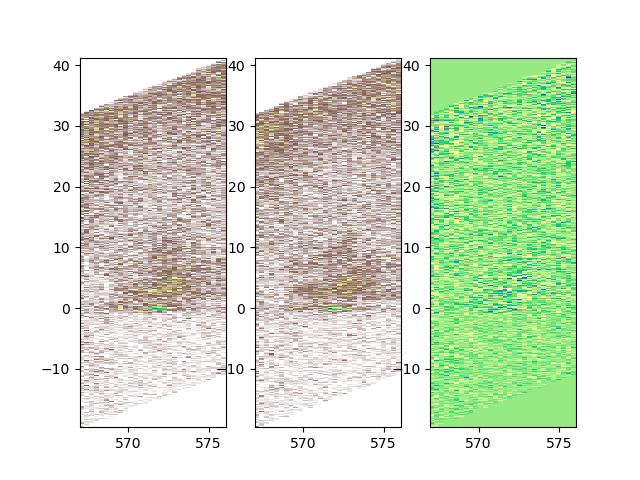

In [62]:
emi,calib =pixel2emi(np.arange(avg['axis_svls_on_sum'].shape[1]), 
            avg['scanvar_on'], 
            avg['axis_svls_on_sum'], calib=[0.06521910251275982, 534.809958523687], 
            points=[[569.5,533],[573.2,589]])

mono, E_trans_on, data_trans_on=emi2ET(avg['scanvar_on'],emi,avg['axis_svls_on_sum'],step=0.1)
mono, E_trans_off, data_trans_off=emi2ET(avg['scanvar_off'],emi,avg['axis_svls_off_sum'],step=0.1)

fig,ax=plt.subplots(1,3)
ax[0].pcolor(mono,E_trans_on, data_trans_on.T,cmap='terrain_r',vmin=-0,vmax=np.max(data_trans))
ax[1].pcolor(mono,E_trans_off, data_trans_off.T,cmap='terrain_r',vmin=-0,vmax=np.max(data_trans))
ax[2].pcolor(mono,E_trans_on, (data_trans_on-data_trans_off).T,vmin=np.min((data_trans_on-data_trans_off)),cmap='terrain_r',vmax=np.max((data_trans_on-data_trans_off)))

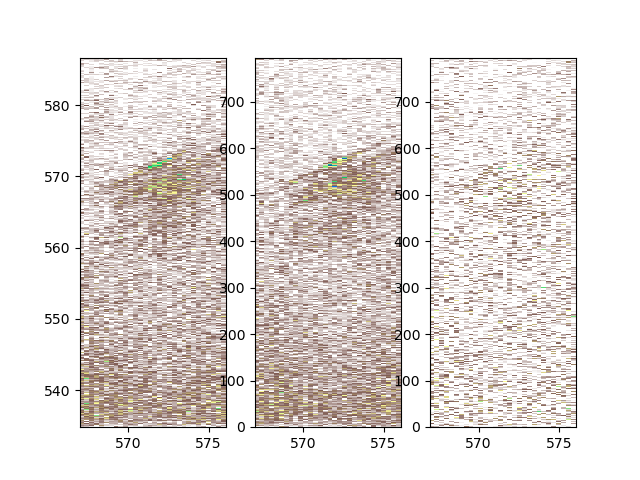

In [53]:
fig,ax=plt.subplots(1,3)
ax[0].pcolor(avg['scanvar_on'],emi,avg['axis_svls_on_sum'].T,cmap='terrain_r',vmin=-0,vmax=np.max(avg['axis_svls_on_sum']))
ax[1].pcolor(avg['scanvar_off'],np.arange(avg['axis_svls_off_sum'].shape[1]),avg['axis_svls_off_sum'].T,cmap='terrain_r',vmin=-0,vmax=np.max(avg['axis_svls_off_sum']))
ax[2].pcolor(avg['scanvar_off'],np.arange(avg['axis_svls_off_sum'].shape[1]),(avg['axis_svls_on_sum']-avg['axis_svls_off_sum']).T,cmap='terrain_r',vmin=-0,vmax=np.max(avg['axis_svls_on_sum']-avg['axis_svls_off_sum']))



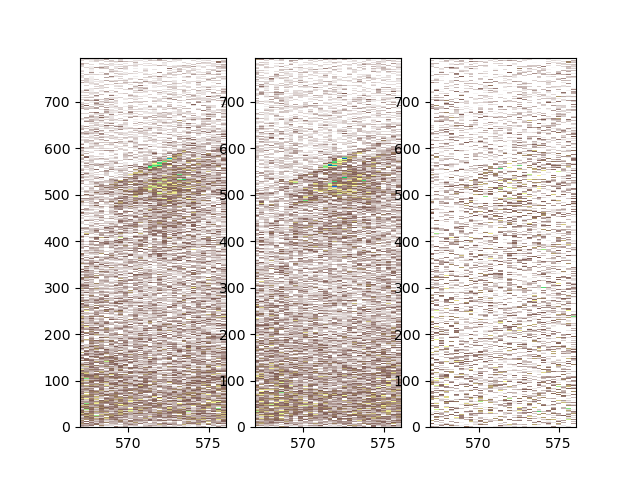

In [4]:

fig,ax=plt.subplots(1,3)
ax[0].pcolor(red.scanvar_on,np.arange(red.axis_svls_on_mean.shape[1]),red.axis_svls_on_mean.T,cmap='terrain_r',vmin=-0,vmax=np.max(red.axis_svls_off_mean))
ax[1].pcolor(red.scanvar_off,np.arange(red.axis_svls_off_mean.shape[1]),red.axis_svls_off_mean.T,cmap='terrain_r',vmin=0,vmax=np.max(red.axis_svls_off_mean))
ax[2].pcolor(red.scanvar_on,np.arange(red.axis_svls_on_mean.shape[1]),red.axis_svls_on_mean.T-red.axis_svls_off_mean.T,cmap='terrain_r',vmin=-0,vmax=np.max(red.axis_svls_on_mean-red.axis_svls_off_mean))


In [ ]:
data.singleshot.fim_0.full_area
bg_roi=[0,50]
bg = np.mean(data.singleshot.fim_0.full_area[...,bg_roi[0]:bg_roi[1]],axis= -1)
bgf = data.singleshot.fim_0.full_area - bg[...,np.newaxis]

In [ ]:
fim_roi=[60,70]

fim_proc =subtract_bg(data.singleshot.fim_0.full_area,[0,50])
fim_wf_avs = np.nanmean(fim_proc,axis = 0)
# fim = np.sum(np.abs(fim_proc[:,:,fim_roi[0]:fim_roi[1]]),axis = (1,2))

# fim = np.nansum(fim_proc[:,:,fim_roi[0]:fim_roi[1]],axis = (1,2))

fim_sum_all = np.nansum(np.abs(fim_proc[:,:,fim_roi[0]:fim_roi[1]]),axis = 2)

In [5]:
# run=76
# fname = f'/sdf/data/lcls/ds/rix/rix100836924/scratch/h5/rix100836924_Run{run:04d}.h5'
# test = h5py.File(fname, 'r')
#run=142
#fname = f'/sdf/data/lcls/ds/rix/rix100836924/scratch/h5/rix100836924_Run{run:04d}.h5'
run=310
fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
test1 = h5py.File(fname, 'r')
test1['intg']['andor_vls']['scan_sum_lxt_ttc']
# test1['scan']['lxt_ttc']

<HDF5 dataset "scan_sum_lxt_ttc": shape (16292, 1), type "<f8">

In [ ]:
premirror = get_premirror_pitch(red.data.epics['MONO_premirror_pitch'][:])
hrencoder = red.data.integrating.andor_vls.mono_encoder
hr_pitch = hrencoder_to_pitch(hrencoder, red.data.yaml['mono_calib'])
hr_energy = mono_energy(hr_pitch,premirror)
hr_energy

['/epics_archiver/SP1K1_MONO_MMS_M_PI.RBV']


In [1]:
testfile = h5py.File('testsave.h5','w')
keys = vars(red)
avg = {}
for key in keys:
    avg[key] = np.zeros(testfile[key].shape)

for dat in keys:
    if 'on' in dat:
        print(dat)
        testfile.create_dataset(dat,dtype='f',data=keys[dat])
    elif 'off' in dat:
        print(dat)
        testfile.create_dataset(dat,dtype='f',data=keys[dat])


testfile.close()

NameError: name 'h5py' is not defined

In [8]:
runs=[399,400]
avg = {}
with h5py.File(f'./proc/Run{runs[0]:04d}.h5','r') as tmp:
    keys = list(tmp.keys())
    for key in keys:
        avg[key] = np.zeros(tmp[key].shape)

i=0
for run in runs:
    i=i+1
    file = f'./proc/Run{run:04d}.h5'
    for key in keys:    
        with h5py.File(file,'r') as f:
            # print(f.keys())
            if avg[key].shape==f[key].shape:
                avg[key] = avg[key] + f[key]
            else:
                print(f'Run {run} shapes do not match')
for key in keys:
    avg[key] = avg[key]/i



In [11]:
avg['scanvar_on']

array([567.13565063, 567.43847656, 567.74136353, 568.04421997,
       568.34707642, 568.64996338, 568.95281982, 569.25567627,
       569.55853271, 569.86141968, 570.16427612, 570.46710205,
       570.76998901, 571.07284546, 571.3757019 , 571.67855835,
       571.98144531, 572.28430176, 572.5871582 , 572.89004517,
       573.19290161, 573.49572754, 573.79858398, 574.10147095,
       574.40432739, 574.70718384, 575.01004028, 575.31292725,
       575.61578369, 575.91864014])

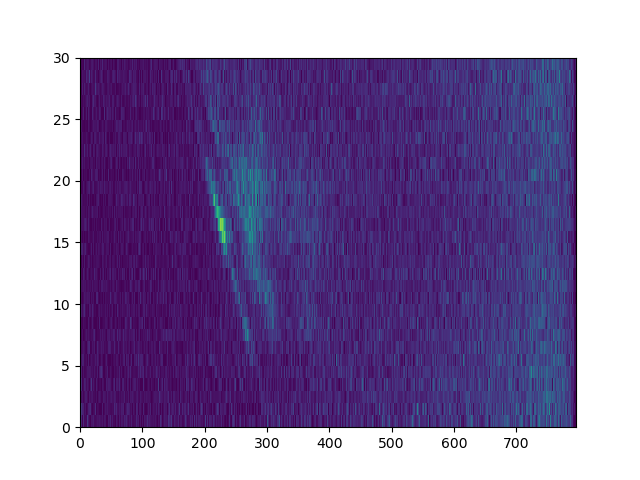

In [18]:
fig,ax=plt.subplots(1,1)
ax.pcolor(avg['axis_svls_off_mean'])

In [ ]:
def average_data_test(datas, detector):
    averaged_data = {}
    
    if detector not in datas[0]:
        raise ValueError(f"Detector '{detector}' not found")
    is_nested_structure = isinstance(datas[0][detector], dict) and ('on' in datas[0][detector] or 'off' in datas[0][detector])
    if not is_nested_structure:
        all_values = []
        
        #determine the shape
        shapes = []
        for data in datas:
            if detector in data:
                shapes.append(np.shape(data[detector]))
        homogeneous_shape = all(shape == shapes[0] for shape in shapes)
        if homogeneous_shape:
            for data in datas:
                if detector in data:
                    all_values.append(data[detector])
            
            all_values = np.array(all_values)
            
            averaged_data['mean'] = np.nanmean(all_values, axis=0)
            averaged_data['std'] = np.nanstd(all_values, axis=0)
            
            #std error
            n_runs = len(all_values)
            if n_runs > 1:
                averaged_data['std_err'] = averaged_data['std'] / np.sqrt(n_runs)
            else:
                averaged_data['std_err'] = np.zeros_like(averaged_data['mean'])
        else:
            print(f"Warning: {detector} has inconsistent shapes across runs. Using only the first run.")
            averaged_data['mean'] = datas[0][detector]
            averaged_data['std'] = np.zeros_like(datas[0][detector])
            averaged_data['std_err'] = np.zeros_like(datas[0][detector])
        
        return averaged_data
    
    # Handle nested structure with on/off
    has_pump_probe = 'on' in datas[0][detector]
    
    # Initialize data collection arrays
    var_off_mean = []
    var_off_std = []
    var_off_sum = []
    frames_per_bin_off = []
    
    if has_pump_probe:
        var_on_mean = []
        var_on_std = []
        var_on_sum = []
        frames_per_bin_on = []
    
    # Collect data from all runs
    for data in datas:
        if detector not in data:
            continue
        
        # Collect 'off' data
        if 'off' in data[detector]:
            var_off_mean.append(data[detector]['off']['mean'])
            var_off_std.append(data[detector]['off']['std'])
            if 'sum' in data[detector]['off']:
                var_off_sum.append(data[detector]['off']['sum'])
            frames_per_bin_off.append(data['frames_per_bin']['off'])
        
        # Collect 'on' data if available
        if has_pump_probe and 'on' in data[detector]:
            var_on_mean.append(data[detector]['on']['mean'])
            var_on_std.append(data[detector]['on']['std'])
            if 'sum' in data[detector]['on']:
                var_on_sum.append(data[detector]['on']['sum'])
            frames_per_bin_on.append(data['frames_per_bin']['on'])
    
    # Process 'off' data
    if var_off_mean:
        # Check if all arrays have the same shape
        shapes = [np.shape(arr) for arr in var_off_mean]
        homogeneous_shape = all(shape == shapes[0] for shape in shapes)
        
        averaged_data['off'] = {}
        
        if homogeneous_shape:
            var_off_mean = np.array(var_off_mean)
            var_off_std = np.array(var_off_std)
            frames_per_bin_off = np.array(frames_per_bin_off)
            
            averaged_data['off']['mean'] = np.nanmean(var_off_mean, axis=0)
            averaged_data['off']['std'] = np.nanstd(var_off_mean, axis=0)
            if var_off_sum:
                var_off_sum = np.array(var_off_sum)
                averaged_data['off']['sum'] = np.nansum(var_off_sum, axis=0)
            
            n_runs = len(var_off_mean)
            averaged_data['off']['std_err'] = averaged_data['off']['std'] / np.sqrt(n_runs)
        else:
            print(f"Warning: {detector} 'off' has inconsistent shapes across runs. Using only the first run.")
            averaged_data['off']['mean'] = var_off_mean[0]
            averaged_data['off']['std'] = var_off_std[0]
            if var_off_sum:
                averaged_data['off']['sum'] = var_off_sum[0]
            averaged_data['off']['std_err'] = var_off_std[0] / np.sqrt(frames_per_bin_off[0])
    
    if has_pump_probe and var_on_mean:
        shapes = [np.shape(arr) for arr in var_on_mean]
        homogeneous_shape = all(shape == shapes[0] for shape in shapes)
        
        averaged_data['on'] = {}
        
        if homogeneous_shape:
            var_on_mean = np.array(var_on_mean)
            var_on_std = np.array(var_on_std)
            frames_per_bin_on = np.array(frames_per_bin_on)
            
            averaged_data['on']['mean'] = np.nanmean(var_on_mean, axis=0)
            averaged_data['on']['std'] = np.nanstd(var_on_mean, axis=0)
            
            if var_on_sum:
                var_on_sum = np.array(var_on_sum)
                averaged_data['on']['sum'] = np.nansum(var_on_sum, axis=0)
            
            n_runs = len(var_on_mean)
            averaged_data['on']['std_err'] = averaged_data['on']['std'] / np.sqrt(n_runs)
        else:
            print(f"Warning: {detector} 'on' has inconsistent shapes across runs. Using only the first run.")
            averaged_data['on']['mean'] = var_on_mean[0]
            averaged_data['on']['std'] = var_on_std[0]
            if var_on_sum:
                averaged_data['on']['sum'] = var_on_sum[0]
            averaged_data['on']['std_err'] = var_on_std[0] / np.sqrt(frames_per_bin_on[0])
    
    return averaged_data

['andor_vls_off_mean',
 'andor_vls_off_std',
 'andor_vls_off_sum',
 'andor_vls_on_mean',
 'andor_vls_on_std',
 'andor_vls_on_sum',
 'axis_svls_off_mean',
 'axis_svls_off_std',
 'axis_svls_off_sum',
 'axis_svls_on_mean',
 'axis_svls_on_std',
 'axis_svls_on_sum',
 'scanvar_off',
 'scanvar_on']